# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

Who?  
- Transportation planning teams: These teams could use the data to insure transportation infrustructure matches the demand that is needed. For example, a highway that had a lot of tuck traffic on might need improvements before a low volume highway.  
- Supply chain and logistics managers: people on the business side that need insight on where the most freight is flowing and which modes of transportation are being used.  
  
What?  
- The freight analysis framework can show patterns in where freight is flowing to and from, what modes of transportration is being used, and what routes have the modet volume.  
  
How?
- Showing the relationships between different origins and destinations.Z
- showing when and how much certain modes of transportation are being used. Also showing how modes of transportation may change over time.
- Focusing on details that have strong or interesting outcomes, rather than showing all analysis.



# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
pd.options.display.float_format = '{:,.0f}'.format


Dataset:   
Freight Analysis Framework (FAF)  
U.S. Department of Transportation, Bureau of Transportation Statistics  
https://www.bts.gov/faf  

In [2]:
df_faf = pd.read_csv('data/faf5.7.1.csv')
print("Number of rows:", len(df_faf))
df_faf.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/faf5.7.1.csv'

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

### Freight analysis framework (FAF) data dictionary:

#### Geographic Fields
- **`fr_orig` / `fr_dest`** FAF regional codes identifying where the freight movement starts and ends.
- **`dms_orig` / `dms_dest`** Domestic Modeled System (DMS) geographic codes used in internal modeling; similar purpose but based on a different zoning system.

#### Mode Fields
- **`fr_inmode`** Mode used for inbound foreign freight (imports).
- **`dms_mode`** Domestic transportation mode used within the U.S.
- **`fr_outmode`** Mode used for outbound foreign freight (exports).

#### Commodity & Trade Fields
- **`sctg2`** Two‑digit SCTG commodity code identifying the type of goods.
- **`trade_type`** Indicates whether the movement is domestic, import, or export.

#### Distance Field
- **`dist_band`** Categorical distance range (e.g., 0–50 miles, 50–250 miles, etc.) used to group flows by travel distance.

#### Freight Flow Measures (Multi‑Year Metrics)
- **`tons_YYYY`** Total tons moved in each year (2017–2050).
- **`value_YYYY`** Inflation‑adjusted value of freight in each year (2017–2050).
- **`current_value_YYYY`** Nominal (current‑dollar) value for selected years (2018–2024).
- **`tmiles_YYYY`** Ton‑miles (tons × distance) for each year (2017–2050).

#### What a Row Represents
Each row represents a single freight movement defined by:
- origin and destination region  
- commodity type  
- domestic and foreign modes  
- trade type  
- distance band 

### Dataset Summary

In [ ]:
print("Size:", df_faf.shape)
print("Column names:", df_faf.columns.tolist())

Size: (2671386, 56)
Column names: ['fr_orig', 'dms_orig', 'dms_dest', 'fr_dest', 'fr_inmode', 'dms_mode', 'fr_outmode', 'sctg2', 'trade_type', 'dist_band', 'tons_2017', 'tons_2018', 'tons_2019', 'tons_2020', 'tons_2021', 'tons_2022', 'tons_2023', 'tons_2024', 'tons_2030', 'tons_2035', 'tons_2040', 'tons_2045', 'tons_2050', 'value_2017', 'value_2018', 'value_2019', 'value_2020', 'value_2021', 'value_2022', 'value_2023', 'value_2024', 'value_2030', 'value_2035', 'value_2040', 'value_2045', 'value_2050', 'current_value_2018', 'current_value_2019', 'current_value_2020', 'current_value_2021', 'current_value_2022', 'current_value_2023', 'current_value_2024', 'tmiles_2017', 'tmiles_2018', 'tmiles_2019', 'tmiles_2020', 'tmiles_2021', 'tmiles_2022', 'tmiles_2023', 'tmiles_2024', 'tmiles_2030', 'tmiles_2035', 'tmiles_2040', 'tmiles_2045', 'tmiles_2050']


In [ ]:
df_faf.info()

<class 'pandas.DataFrame'>
RangeIndex: 2671386 entries, 0 to 2671385
Data columns (total 56 columns):
 #   Column              Dtype  
---  ------              -----  
 0   fr_orig             float64
 1   dms_orig            int64  
 2   dms_dest            int64  
 3   fr_dest             float64
 4   fr_inmode           float64
 5   dms_mode            int64  
 6   fr_outmode          float64
 7   sctg2               int64  
 8   trade_type          int64  
 9   dist_band           int64  
 10  tons_2017           float64
 11  tons_2018           float64
 12  tons_2019           float64
 13  tons_2020           float64
 14  tons_2021           float64
 15  tons_2022           float64
 16  tons_2023           float64
 17  tons_2024           float64
 18  tons_2030           float64
 19  tons_2035           float64
 20  tons_2040           float64
 21  tons_2045           float64
 22  tons_2050           float64
 23  value_2017          float64
 24  value_2018          float64
 25  va

In [ ]:
df_faf.describe()

,fr_orig,dms_orig,dms_dest,fr_dest,fr_inmode,dms_mode,fr_outmode,sctg2,trade_type,dist_band,...,tmiles_2020,tmiles_2021,tmiles_2022,tmiles_2023,tmiles_2024,tmiles_2030,tmiles_2035,tmiles_2040,tmiles_2045,tmiles_2050
count,"1,100,664","2,671,386","2,671,386","1,047,970","1,100,664","2,671,386","1,047,970","2,671,386","2,671,386","2,671,386",...,"2,671,386","2,671,386","2,671,386","2,671,386","2,671,386","2,671,386","2,671,386","2,671,386","2,671,386","2,671,386"
mean,805,292,292,804,3,3,3,27,2,5,...,2,2,2,2,2,2,2,3,3,3
std,2,158,159,2,1,2,1,11,1,2,...,77,81,84,87,84,83,88,94,93,97
min,801,11,11,801,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
25%,803,139,132,803,3,1,3,21,2,3,...,0,0,0,0,0,0,0,0,0,0
50%,804,292,299,804,3,4,3,31,2,5,...,0,0,0,0,0,0,0,0,0,0
75%,807,423,429,806,4,4,4,36,3,7,...,0,0,0,0,0,0,0,0,0,0
max,808,560,560,808,7,8,7,43,3,8,...,"61,932","67,063","73,822","81,189","79,513","57,954","63,890","69,816","60,681","61,981"


### Missing values and duplicates

In [ ]:
null_counts = df_faf.isnull().sum().sort_values(ascending=False)
print("Null value counts for each column:")
print(null_counts)

Null value counts for each column:
fr_dest               1623416
fr_outmode            1623416
fr_inmode             1570722
fr_orig               1570722
dms_dest                    0
dms_orig                    0
dms_mode                    0
sctg2                       0
trade_type                  0
dist_band                   0
tons_2017                   0
tons_2018                   0
tons_2019                   0
tons_2020                   0
tons_2021                   0
tons_2022                   0
tons_2023                   0
tons_2024                   0
tons_2030                   0
tons_2035                   0
tons_2040                   0
tons_2045                   0
tons_2050                   0
value_2017                  0
value_2018                  0
value_2019                  0
value_2020                  0
value_2021                  0
value_2022                  0
value_2023                  0
value_2024                  0
value_2030                  0
value

In [ ]:
duplicate_counts = df_faf.duplicated().sum()
print("Number of duplicate rows:", duplicate_counts) 

Number of duplicate rows: 0


### Adding one hot encoded columns

In [ ]:
#check number of unigue values in each column
df_faf.nunique()

fr_orig                    8
dms_orig                 132
dms_dest                 132
fr_dest                    8
fr_inmode                  7
dms_mode                   8
fr_outmode                 7
sctg2                     42
trade_type                 3
dist_band                  8
tons_2017             471386
tons_2018             503368
tons_2019             498021
tons_2020             493749
tons_2021             503269
tons_2022             507277
tons_2023             496629
tons_2024             498313
tons_2030             506289
tons_2035             518907
tons_2040             531852
tons_2045             544827
tons_2050             558320
value_2017            750474
value_2018            795438
value_2019            792763
value_2020            783176
value_2021            795818
value_2022            801451
value_2023            787659
value_2024            792791
value_2030            816063
value_2035            831661
value_2040            848191
value_2045    

In [ ]:
df_encoded = pd.get_dummies(df_faf, columns=['fr_orig', 'fr_dest', 'fr_inmode', 'fr_outmode', 'trade_type', 'dist_band'])
df_encoded.head()

,dms_orig,dms_dest,dms_mode,sctg2,tons_2017,tons_2018,tons_2019,tons_2020,tons_2021,tons_2022,...,trade_type_2,trade_type_3,dist_band_1,dist_band_2,dist_band_3,dist_band_4,dist_band_5,dist_band_6,dist_band_7,dist_band_8
0,11,11,1,1,51,52,54,54,56,56,...,False,False,True,False,False,False,False,False,False,False
1,11,19,1,1,386,392,408,411,424,427,...,False,False,False,True,False,False,False,False,False,False
2,11,129,1,1,1,1,1,1,1,2,...,False,False,False,False,True,False,False,False,False,False
3,11,131,1,1,12,13,13,13,14,14,...,False,False,False,True,False,False,False,False,False,False
4,11,139,1,1,5,5,5,5,6,6,...,False,False,False,True,False,False,False,False,False,False


In [ ]:
df_encoded.columns

Index(['dms_orig', 'dms_dest', 'dms_mode', 'sctg2', 'tons_2017', 'tons_2018',
       'tons_2019', 'tons_2020', 'tons_2021', 'tons_2022', 'tons_2023',
       'tons_2024', 'tons_2030', 'tons_2035', 'tons_2040', 'tons_2045',
       'tons_2050', 'value_2017', 'value_2018', 'value_2019', 'value_2020',
       'value_2021', 'value_2022', 'value_2023', 'value_2024', 'value_2030',
       'value_2035', 'value_2040', 'value_2045', 'value_2050',
       'current_value_2018', 'current_value_2019', 'current_value_2020',
       'current_value_2021', 'current_value_2022', 'current_value_2023',
       'current_value_2024', 'tmiles_2017', 'tmiles_2018', 'tmiles_2019',
       'tmiles_2020', 'tmiles_2021', 'tmiles_2022', 'tmiles_2023',
       'tmiles_2024', 'tmiles_2030', 'tmiles_2035', 'tmiles_2040',
       'tmiles_2045', 'tmiles_2050', 'fr_orig_801.0', 'fr_orig_802.0',
       'fr_orig_803.0', 'fr_orig_804.0', 'fr_orig_805.0', 'fr_orig_806.0',
       'fr_orig_807.0', 'fr_orig_808.0', 'fr_dest_801.0', 'fr_

### Checking for class imbalances

In [ ]:
#Class counts for 'fr_orig', 'fr_dest', 'fr_inmode', 'fr_outmode', 'trade_type', 'dist_band'
df_faf.groupby(['fr_orig']).size()


fr_orig
801    147710
802     88692
803    108322
804    235068
805     62087
806    133388
807    194825
808    130572
dtype: int64

In [ ]:
df_faf.groupby(['fr_dest']).size().sort_values(ascending=False)

fr_dest
804    176336
801    166470
807    135859
803    135227
806    128847
808    124823
802     93432
805     86976
dtype: int64

In [ ]:
df_faf.groupby(['fr_inmode']).size().sort_values(ascending=False)

fr_inmode
4    474675
3    474066
1     63045
5     47482
2     25205
7     15764
6       427
dtype: int64

In [ ]:
df_faf.groupby(['fr_outmode']).size().sort_values(ascending=False)

fr_outmode
4    476603
3    420277
1     74246
2     32849
5     30020
7     13369
6       606
dtype: int64

In [ ]:
df_faf.groupby(['trade_type']).size().sort_values(ascending=False)

trade_type
2    1100664
3    1047970
1     522752
dtype: int64

In [ ]:
df_faf.groupby(['dist_band']).size().sort_values(ascending=False)

dist_band
8    482449
6    453900
3    407519
4    361414
5    333417
7    279896
2    246925
1    105866
dtype: int64

### Conclusion

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

In [ ]:
import matplotlib.pyplot as plt
# Plotting the freight mode tonnage by year
#plt.figure(figsize=(10, 6))
#df_faf.groupby('dms_mode')['2020'].sum().plot(kind='bar')

tonage_by_year = df_faf.groupby('dms_mode').sum().filter(like='tons_').transpose()

dms_mode,1,2,3,4,5,6,7,8
tons_2017,"12,800,257","1,615,503","914,839","6,470","687,874","3,450,603","102,198","208,641"
tons_2018,"12,958,550","1,639,486","852,376","6,691","671,999","3,788,801","100,274","192,329"
tons_2019,"12,851,623","1,598,599","818,926","6,540","653,403","3,903,958","95,965","136,038"
tons_2020,"12,436,962","1,440,743","742,895","6,508","622,565","3,703,598","82,861","103,734"
tons_2021,"12,728,502","1,533,374","765,260","7,434","626,010","3,830,880","85,448","112,034"
tons_2022,"12,667,943","1,566,017","776,690","7,810","627,364","3,982,092","86,162","113,108"
tons_2023,"12,741,507","1,593,807","787,689","6,584","635,781","4,053,466","83,974","119,792"
tons_2024,"12,843,949","1,532,843","771,511","6,701","634,480","4,025,257","80,348","116,413"
tons_2030,"14,461,796","1,535,757","989,863","8,122","817,584","4,305,253","66,175","123,808"
tons_2035,"15,369,180","1,572,934","1,026,994","9,103","887,307","4,513,841","54,188","114,127"


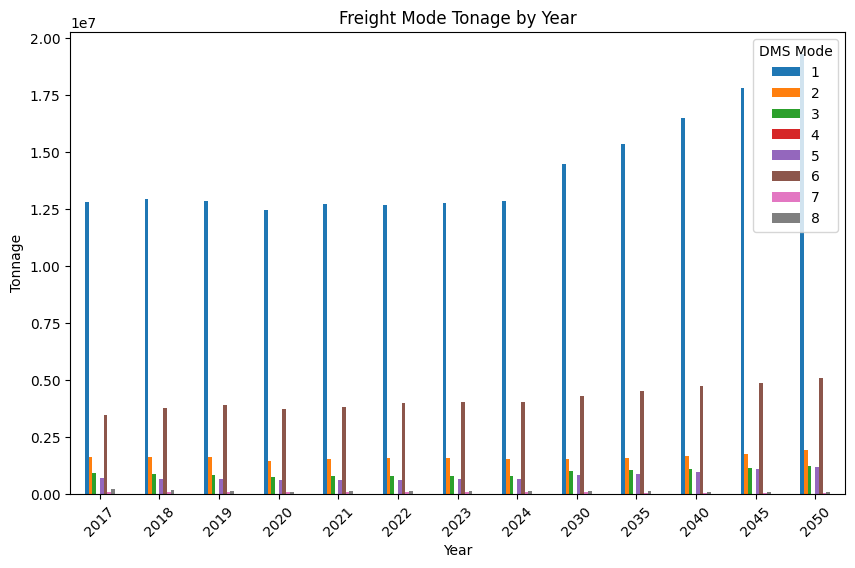

In [ ]:
tonage_by_year.plot(kind='bar', figsize=(10, 6))
plt.title('Freight Mode Tonage by Year')
plt.xlabel('Year')
plt.ylabel('Tonnage')
plt.xticks(rotation=45)
plt.legend(title='DMS Mode')
#remove tons_ from the x-axis labels
plt.xticks(ticks=range(len(tonage_by_year.index)), labels=tonage_by_year.index.str.replace('tons_', ''));

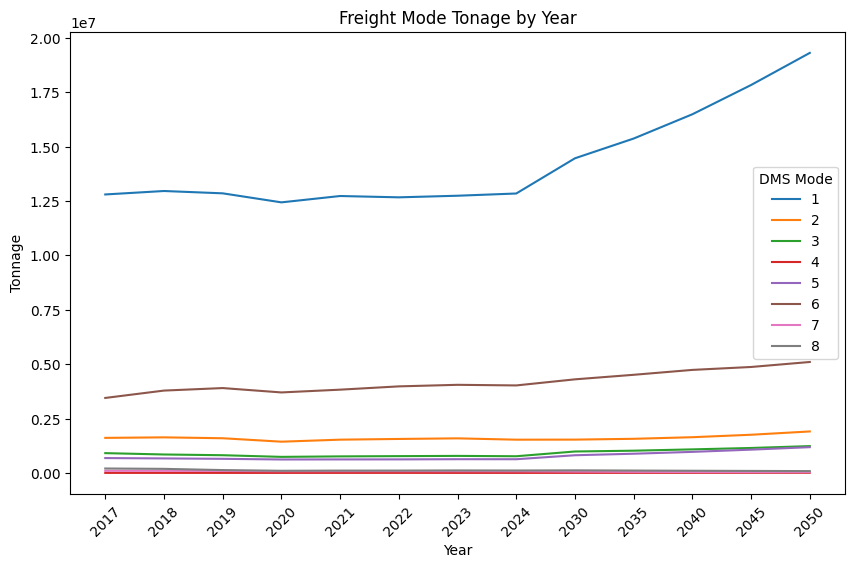

In [ ]:
tonage_by_year.plot(kind='line', figsize=(10, 6))
plt.title('Freight Mode Tonage by Year')
plt.xlabel('Year')
plt.ylabel('Tonnage')
plt.xticks(rotation=45)
plt.legend(title='DMS Mode')

#remove tons_ from the x-axis labels
plt.xticks(ticks=range(len(tonage_by_year.index)), labels=tonage_by_year.index.str.replace('tons_', ''));